In [5]:
suppressMessages(library("rwwa"))

In [ ]:
synth_obs <- function (obs_in, synth_type = "abs") {

    colnames(obs_in) <- c("est", "lower", "upper")
    
    if (!synth_type %in% c("abs", "rel", "PR")) {
        cat(paste0("Synthesis type '", synth_type, "' not implemented - must be abs, rel or PR"), 
            "\n")
    }
    if (synth_type == "PR") {
        obs_in[, c("est", "lower", "upper")] <- log(obs_in[, 
            c("est", "lower", "upper")])
    }
    else if (synth_type == "rel") {
        obs_in[, c("est", "lower", "upper")] <- log(1 + obs_in[, 
            c("est", "lower", "upper")]/100)
    }
    nobs = nrow(obs_in)
    obs <- apply(obs_in[, c("est", "lower", "upper"), drop = F], 
        2, mean)
    if (nobs == 1) {
        sig_obs = 0
    }
    else {
        s2 = sum((obs_in$est - obs[1])^2)
        sig_obs = sqrt(s2/(nobs - 1))
    }
    obs_in$l_wb <- obs_in$est - sqrt((obs_in$est - obs_in$lower)^2 + 
        (1.96 * sig_obs)^2)
    obs_in$u_wb <- obs_in$est + sqrt((obs_in$est - obs_in$upper)^2 + 
        (1.96 * sig_obs)^2)
    obs[2] <- obs[1] - sqrt((obs[1] - obs[2])^2 + (1.96 * sig_obs)^2)
    obs[3] <- obs[1] + sqrt((obs[1] - obs[3])^2 + (1.96 * sig_obs)^2)
    
    obs_in <- cbind(obs_in, "model" = rownames(obs_in), group = "obs")
    obs <- data.frame(t(c(model = "Observations", group = "obs_synth", obs)))
    res <- rbind.fill(obs_in, obs)[, c("group", "model", "est", "lower", "upper", "l_wb", "u_wb")]
    
    for (cnm in c("est", "lower", "upper", "l_wb", "u_wb")) { res[, cnm] <- as.numeric(res[, cnm]) }
    if (synth_type == "PR") {
        res[, c("est", "lower", "upper", "l_wb", "u_wb")] <- exp(res[, c("est", "lower", "upper", "l_wb", "u_wb")])
    }
    else if (synth_type == "rel") {
        res[, c("est", "lower", "upper", "l_wb", "u_wb")] <- 100 * (exp(res[, c("est", "lower", "upper", "l_wb", "u_wb")]) - 1)
    }
    return(list(synth_type = synth_type, df = res))
}

plot_synthesis(synth_obs(read.csv("dI_stations.csv", row.names = "X")), add_space = F)

In [21]:
synth_obs(read.csv("dI_stations.csv", row.names = "X"))

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,USW00013733,-14.757130,-47.00383,29.58357,-71.50632,49.637883
obs,USW00013741,-32.044859,-58.85580,15.22131,-85.89137,34.398434
obs,USW00013743,-5.284566,-51.68611,63.99866,-71.11559,78.266529
obs,USW00013877,-50.285784,-72.13897,-20.10268,-101.84334,5.316736
obs,USW00013967,-1.464714,-45.16485,66.73769,-65.42034,81.192336
obs,USW00023042,-17.637405,-64.25823,74.39487,-83.62317,85.564147
obs,USW00023047,24.947900,-21.00903,98.14283,-40.57049,111.770232
obs_synth,Observations,-13.789508,-73.77764,62.74953,NA,NA


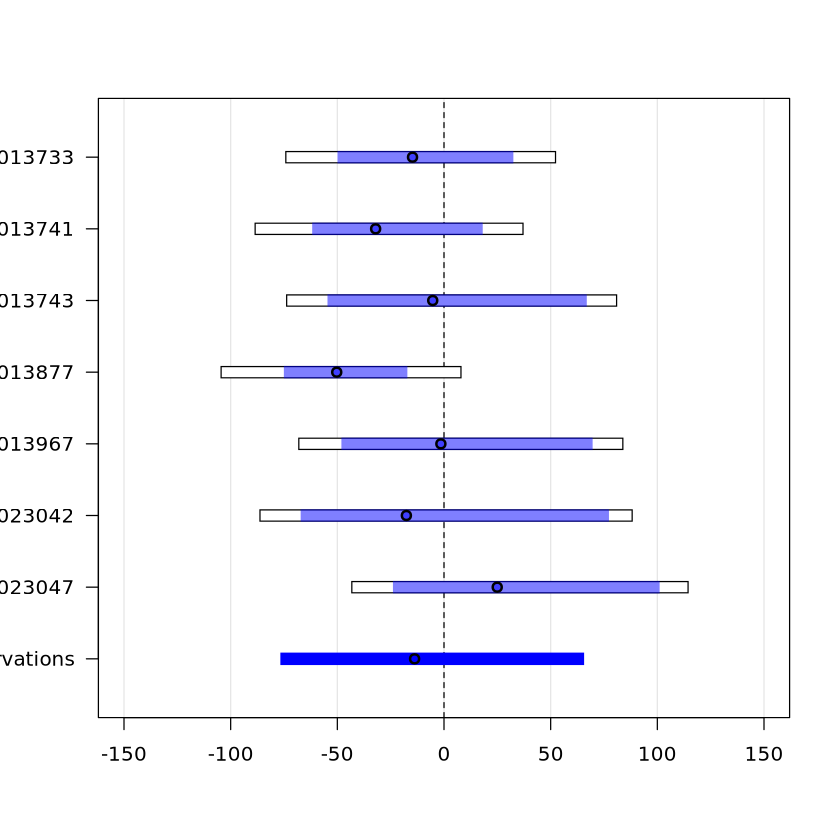

In [22]:
plot_synthesis(synth_obs(read.csv("dI_stations.csv", row.names = "X")), add_space = F)